# Agentic AI

### import required packages

In [13]:
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from typing_extensions import TypedDict
from langchain_openai import ChatOpenAI
from IPython.display import Image

### creating the state

In [2]:
class AppState(TypedDict):
    message: str

### create llm

In [7]:
load_dotenv()

llm = ChatOpenAI(model="gpt-5")

### define required tools

In [26]:
# tool1
def function_tool1(state: AppState):
    """this tool is used to get result by sending prompt to LLM"""
    print(f"inside fuction_tool1, state => {state}")
    
    # state message contains the prompt sent by the user
    result = llm.invoke(state['message'])
    print(f"result = {result.content}")

    return {"message": result.content}
    

In [23]:
# tool2
def function_tool2(state: AppState):
    print(f"state = {state}")

    # modify and return new values
    return {"message": state['message'] + " > updated by function_tool2"}

### create the graph

In [17]:
# create workflow
workflow = StateGraph(AppState)

In [18]:
# add the required tools/nodes
workflow.add_node("tool_llm", function_tool1)
workflow.add_node("tool_second", function_tool2)

In [25]:
# add required edges
workflow.add_edge(START, "tool_llm")
workflow.add_edge("tool_llm", "tool_second")
workflow.add_edge("tool_second", END)
# workflow.add_conditional_edges()

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [20]:
# compile the workflow to create the graph
graph = workflow.compile()

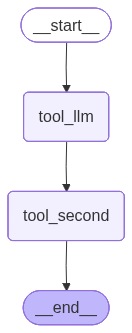

In [21]:
# render the graph
Image(graph.get_graph().draw_mermaid_png())

### use graph

In [24]:
result = graph.invoke({"message": "what is the capital of India?"})
result

inside fuction_tool1, state => {'message': 'what is the capital of India?'}
result = New Delhi.
state = {'message': 'New Delhi.'}


{'message': 'New Delhi. > updated by function_tool1'}